In [39]:
# Cell 1: Setup
import re
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults

load_dotenv()

llm = ChatOpenAI(model="gpt-4o-mini")
search_tool = TavilySearchResults(max_results=2)
from typing import TypedDict
from langgraph.graph import StateGraph, END

In [40]:
# Cell 2: Shared State
class State(TypedDict):
    messages: list
    next: str
    result: str
    history: list  # list of {"step": worker_name, "output": result_str}

In [41]:
# Cell 3: Leaf Workers
def _extract_two_operands(task: str, prev_result: str):
    """If a previous numeric result exists, use it as the first operand and pull
    the next number from the task. Otherwise pull the first two numbers from the task."""
    task_nums = re.findall(r"\d+\.?\d*", task)
    if prev_result:
        prev_nums = re.findall(r"-?\d+\.?\d*", prev_result)
        if prev_nums:
            used = set()
            a = float(prev_nums[0])
            # pick the first task number not already represented in prev_result
            for n in task_nums:
                if n not in used and float(n) != a:
                    return a, float(n)
                used.add(n)
            if task_nums:
                return a, float(task_nums[-1])
    return float(task_nums[0]), float(task_nums[1])

def add_agent(state: State) -> State:
    task = state["messages"][-1]
    a, b = _extract_two_operands(task, state.get("result", ""))
    out = str(a + b)
    history = state.get("history", []) + [{"step": "add", "output": out}]
    return {"result": out, "messages": state["messages"], "history": history}

def multiply_agent(state: State) -> State:
    task = state["messages"][-1]
    a, b = _extract_two_operands(task, state.get("result", ""))
    out = str(a * b)
    history = state.get("history", []) + [{"step": "multiply", "output": out}]
    return {"result": out, "messages": state["messages"], "history": history}

def evaluate_agent(state: State) -> State:
    prompt = f"Answer True or False only. Question: {state['messages'][-1]}"
    response = llm.invoke(prompt)
    out = response.content.strip()
    history = state.get("history", []) + [{"step": "evaluate", "output": out}]
    return {"result": out, "messages": state["messages"], "history": history}

def compare_agent(state: State) -> State:
    prompt = f"State which value is larger in one sentence. Question: {state['messages'][-1]}"
    response = llm.invoke(prompt)
    out = response.content.strip()
    history = state.get("history", []) + [{"step": "compare", "output": out}]
    return {"result": out, "messages": state["messages"], "history": history}

def search_agent(state: State) -> State:
    query = state["messages"][-1]
    results = search_tool.invoke(query)
    content = results[0]["content"] if results else "No results found."
    history = state.get("history", []) + [{"step": "search", "output": content}]
    return {"result": content, "messages": state["messages"], "history": history}

def summarize_agent(state: State) -> State:
    prompt = f"Summarize the following in 2-3 sentences:\n{state['result']}"
    response = llm.invoke(prompt)
    out = response.content.strip()
    history = state.get("history", []) + [{"step": "summarize", "output": out}]
    return {"result": out, "messages": state["messages"], "history": history}

In [42]:
# Cell 4: Arithmetic Subgraph
def _format_history(history):
    if not history:
        return "(no steps completed yet)"
    return "\n".join(f"- {h['step']}: {h['output']}" for h in history)

def arithmetic_supervisor(state: State) -> State:
    history = state.get("history", [])
    prompt = f"""You are an arithmetic supervisor coordinating workers to solve a multi-step task.
Workers available:
- add: adds two numbers
- multiply: multiplies two numbers
- END: signal that the task is fully complete

Original task: {state["messages"][-1]}
Steps completed so far:
{_format_history(history)}
Latest intermediate result: {state.get("result", "") or "(none)"}

Decide the NEXT step. If all parts of the original task have been computed, reply END.
Otherwise reply with the next worker to call.
Reply with ONLY one word: add, multiply, or END"""
    response = llm.invoke(prompt)
    next = response.content.strip().lower()
    print(f"[arithmetic_supervisor] -> {next}")
    return {"next": next, "messages": state["messages"], "result": state.get("result", ""), "history": history}

def route_arithmetic(state: State) -> str:
    return {"add": "add_agent", "multiply": "multiply_agent"}.get(state["next"], END)

arith_builder = StateGraph(State)
arith_builder.add_node("arithmetic_supervisor", arithmetic_supervisor)
arith_builder.add_node("add_agent", add_agent)
arith_builder.add_node("multiply_agent", multiply_agent)
arith_builder.set_entry_point("arithmetic_supervisor")
arith_builder.add_conditional_edges("arithmetic_supervisor", route_arithmetic, {
    "add_agent": "add_agent", "multiply_agent": "multiply_agent", END: END
})
arith_builder.add_edge("add_agent", "arithmetic_supervisor")
arith_builder.add_edge("multiply_agent", "arithmetic_supervisor")
arithmetic_subgraph = arith_builder.compile()

In [43]:
# Cell 5: Logic Subgraph
def logic_supervisor(state: State) -> State:
    history = state.get("history", [])
    prompt = f"""You are a logic supervisor coordinating workers to solve a multi-step task.
Workers available:
- evaluate: answers True/False questions
- compare: states which value is larger
- END: signal that the task is fully complete

Original task: {state["messages"][-1]}
Steps completed so far:
{_format_history(history)}
Latest intermediate result: {state.get("result", "") or "(none)"}

Decide the NEXT step. If all parts of the original task have been answered, reply END.
Otherwise reply with the next worker to call.
Reply with ONLY one word: evaluate, compare, or END"""
    response = llm.invoke(prompt)
    next = response.content.strip().lower()
    print(f"[logic_supervisor] -> {next}")
    return {"next": next, "messages": state["messages"], "result": state.get("result", ""), "history": history}

def route_logic(state: State) -> str:
    return {"evaluate": "evaluate_agent", "compare": "compare_agent"}.get(state["next"], END)

logic_builder = StateGraph(State)
logic_builder.add_node("logic_supervisor", logic_supervisor)
logic_builder.add_node("evaluate_agent", evaluate_agent)
logic_builder.add_node("compare_agent", compare_agent)
logic_builder.set_entry_point("logic_supervisor")
logic_builder.add_conditional_edges("logic_supervisor", route_logic, {
    "evaluate_agent": "evaluate_agent", "compare_agent": "compare_agent", END: END
})
logic_builder.add_edge("evaluate_agent", "logic_supervisor")
logic_builder.add_edge("compare_agent", "logic_supervisor")
logic_subgraph = logic_builder.compile()

In [44]:
# Cell 6: WebSearch Subgraph
def websearch_supervisor(state: State) -> State:
    history = state.get("history", [])
    done_steps = {h["step"] for h in history}
    if "search" not in done_steps:
        next_step = "search"
    elif "summarize" not in done_steps:
        next_step = "summarize"
    else:
        next_step = "end"
    print(f"[websearch_supervisor] -> {next_step}")
    return {"next": next_step, "messages": state["messages"], "result": state.get("result", ""), "history": history}

def route_websearch(state: State) -> str:
    return {"search": "search_agent", "summarize": "summarize_agent"}.get(state["next"], END)

ws_builder = StateGraph(State)
ws_builder.add_node("websearch_supervisor", websearch_supervisor)
ws_builder.add_node("search_agent", search_agent)
ws_builder.add_node("summarize_agent", summarize_agent)
ws_builder.set_entry_point("websearch_supervisor")
ws_builder.add_conditional_edges("websearch_supervisor", route_websearch, {
    "search_agent": "search_agent", "summarize_agent": "summarize_agent", END: END
})
ws_builder.add_edge("search_agent", "websearch_supervisor")
ws_builder.add_edge("summarize_agent", "websearch_supervisor")
websearch_subgraph = ws_builder.compile()

In [45]:
# Cell 7: Top-Level Graph
def top_supervisor(state: State) -> State:
    history = state.get("history", [])
    prompt = f"""You are the top-level supervisor routing to domain teams.
Teams available:
- arithmetic: for addition and multiplication problems
- logic: for True/False questions and comparisons between values
- websearch: for searching and summarizing web content
- END: signal that the original task is fully solved

Original task: {state["messages"][-1]}
Steps completed so far:
{_format_history(history)}
Latest result: {state.get("result", "") or "(none)"}

If the original task is fully solved, reply END.
Otherwise reply with the next team to call.
Reply with ONLY one word: arithmetic, logic, websearch, or END"""
    response = llm.invoke(prompt)
    next = response.content.strip().lower()
    print(f"[top_supervisor] -> {next}")
    return {"next": next, "messages": state["messages"], "result": state.get("result", ""), "history": history}

def route_top(state: State) -> str:
    return {
        "arithmetic": "arithmetic_subgraph",
        "logic": "logic_subgraph",
        "websearch": "websearch_subgraph",
    }.get(state["next"], END)

top_builder = StateGraph(State)
top_builder.add_node("top_supervisor", top_supervisor)
top_builder.add_node("arithmetic_subgraph", arithmetic_subgraph)
top_builder.add_node("logic_subgraph", logic_subgraph)
top_builder.add_node("websearch_subgraph", websearch_subgraph)
top_builder.set_entry_point("top_supervisor")
top_builder.add_conditional_edges("top_supervisor", route_top, {
    "arithmetic_subgraph": "arithmetic_subgraph",
    "logic_subgraph": "logic_subgraph",
    "websearch_subgraph": "websearch_subgraph",
    END: END,
})
top_builder.add_edge("arithmetic_subgraph", "top_supervisor")
top_builder.add_edge("logic_subgraph", "top_supervisor")
top_builder.add_edge("websearch_subgraph", "top_supervisor")
app = top_builder.compile()

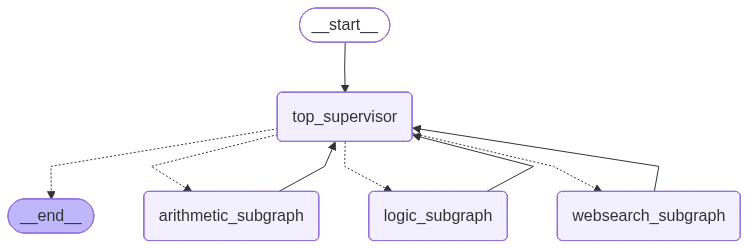

In [46]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

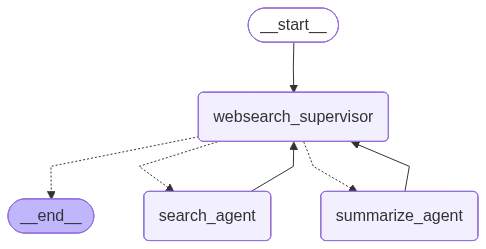

In [47]:
from IPython.display import Image, display
display(Image(websearch_subgraph.get_graph().draw_mermaid_png()))

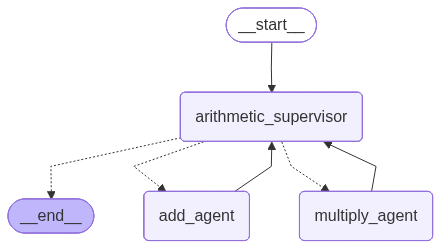

In [48]:
from IPython.display import Image, display
display(Image(arithmetic_subgraph.get_graph().draw_mermaid_png()))

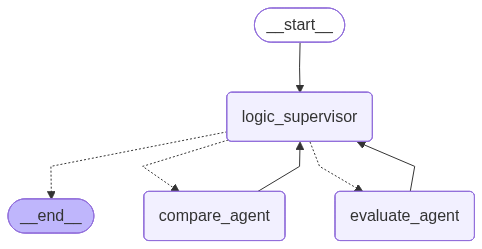

In [49]:
from IPython.display import Image, display
display(Image(logic_subgraph.get_graph().draw_mermaid_png()))

In [50]:
r1 = app.invoke({"messages": ["What is 7 multiplied by 6 and add it by 5?"], "next": "", "result": "", "history": []})
print("Result:", r1["result"])
print("History:", r1["history"])

[top_supervisor] -> arithmetic
[arithmetic_supervisor] -> multiply
[arithmetic_supervisor] -> add
[arithmetic_supervisor] -> end
[top_supervisor] -> end
Result: 49.0
History: [{'step': 'multiply', 'output': '42.0'}, {'step': 'add', 'output': '49.0'}]


In [53]:
r2 = app.invoke({"messages": ["Is 100 greater than 200?"], "next": "", "result": "", "history": []})
print("Result:", r2["result"])
print("History:", r2["history"])

[top_supervisor] -> logic
[logic_supervisor] -> evaluate
[logic_supervisor] -> end
[top_supervisor] -> end
Result: False
History: [{'step': 'evaluate', 'output': 'False'}]


In [52]:
r3 = app.invoke({"messages": ["Search for what is LangGraph and summarize it"], "next": "", "result": "", "history": []})
print("Result:", r3["result"])
print("History:", r3["history"])

[top_supervisor] -> websearch
[websearch_supervisor] -> search
[websearch_supervisor] -> summarize
[websearch_supervisor] -> end
[top_supervisor] -> end
Result: LangGraph is a low-level orchestration framework and runtime designed for building and managing stateful agents, utilized by companies like Klarna, Uber, and J.P. Morgan. It emphasizes agent orchestration capabilities such as durable execution and human-in-the-loop processes, and while it integrates well with LangChain components, users are not required to use LangChain to utilize LangGraph. For those new to agents or seeking a simpler approach, LangChain’s higher-level agents are recommended.
History: [{'step': 'search', 'output': 'Trusted by companies shaping the future of agents— including Klarna, Uber, J.P. Morgan, and more— LangGraph is a low-level orchestration framework and runtime for building, managing, and deploying long-running, stateful agents. LangGraph is very low-level, and focused entirely on agent orchestration